# Niche Query on CCF Dataset


Experiment setup:
- Niche: k-hop neighboring cells within the same brain section;
- Niche: all neighboring cells within the same brain section;
- Niche: cross brain section k-hop neighbouring cells;
- Positive pairs: samples from the same brain section and visualization by prob.

## Load Data

In [1]:

import logging

# sys.path.insert(0, str(Path.cwd().parent.parent / "src"))
logging.basicConfig(level=logging.INFO)

## Gene Expressions

In [ ]:
from src.NicheQueryPrototype.database import Database
from src.NicheQueryPrototype.niche import Niche

# step 1: create db
data_folder = 'notebook/ccf/data/zhuang-abca-1/'
db = Database()
db.construct(adata_path=[data_folder + 'Zhuang-ABCA-1-raw.h5ad'],
             cell_metadata_path=[data_folder + 'cell_metadata.csv'],
             ccf_coordinates_path=[data_folder + 'ccf_coordinates.csv'],
             feature_name='gene_expression',
             parcellation_path='notebook/ccf/data/parcellation/structure.json')

INFO:src.NicheQueryPrototype.database:Loading adata...
INFO:src.NicheQueryPrototype.database:Loading cell metadata...
INFO:src.NicheQueryPrototype.database:Constructing parcellation tree...
INFO:src.NicheQueryPrototype.database:Constructing database for niche query...


In [3]:
# step 2: construct niche to query
niche_to_query = Niche()
niche_to_query.construct_by_k_hop(db, center_cell=None, sample_id='Zhuang-ABCA-1.086', k=10, cell_limit=100,
                                  parcellation_index=987)

INFO:src.NicheQueryPrototype.niche:Constructing k-hop graph..
INFO:src.NicheQueryPrototype.niche:Computing niche feature..
INFO:src.NicheQueryPrototype.niche:Finished computing niche feature with 100 cells on Zhuang-ABCA-1.086 slice.


INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.086
INFO:src.NicheQueryPrototype.niche:[SKIP] finish sample: Zhuang-ABCA-1.086
/var/folders/cb/yd_h3b5576d6wq5rydwp3_kr0000gn/T/ipykernel_18171/379531524.py:149: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(sample.adata, color='niche_query_result', ax=axes[i], show=False, spot_size=5,


KeyError: "Could not find 'spatial' or 'X_spatial' in .obsm"

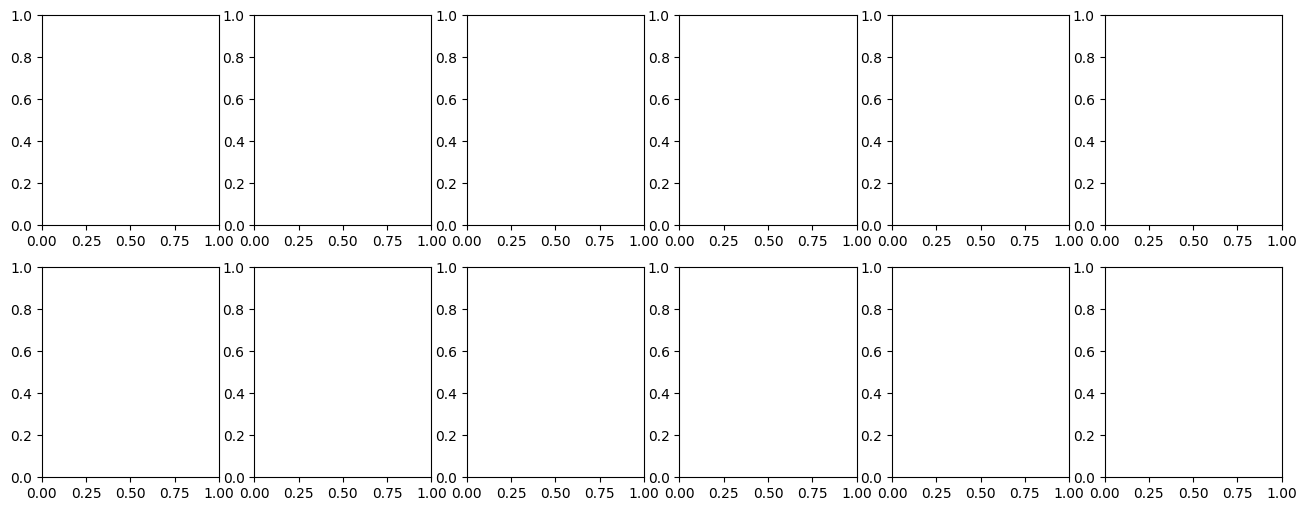

In [14]:
from typing import List, Tuple

import numpy as np
from sklearn.metrics import precision_recall_curve, classification_report
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.neighbors import kneighbors_graph
from sklearn.preprocessing import normalize
import matplotlib.pyplot as plt

from src.NicheQueryPrototype.database import Database, Sample
import scanpy as sc
from src.NicheQueryPrototype.niche import Niche, logger


class NicheQuery:
    def __init__(self, db: Database, niche: Niche, k: int):
        assert 0 < k <= 10, "Invalid subgraph parameter, should be between 1 and 10 (included)"
        self.db = db
        self.niche = niche
        self.k = k

    def get_parcellation_mask(self, sample: Sample) -> np.ndarray:
        parcellation_indices = np.array([c.parcellation_index for c in sample.cells])
        return (parcellation_indices == self.niche.parcellation_index).astype(int)

    """
    Generate niche embedding and parcellation mask for all samples.
    """

    def generate_niche_features_and_parcellation_mask(self, samples: List[Sample], overwrite=False):
        for sample in samples:
            logger.info(f"[START] start computing niche features for sample {sample.id}")
            if not overwrite and sample.niche_features is not None and sample.target_parcellation_mask is not None:
                logger.info(f"[SKIP] finish sample: {sample.id}")
                continue
            sample_features = np.array([c.feature.squeeze() for c in sample.cells])
            sample.target_parcellation_mask = self.get_parcellation_mask(sample)
            niche_connectivity = kneighbors_graph(
                sample_features,
                n_neighbors=self.k,
                mode="connectivity",
                metric="euclidean",
                include_self=True,
            )
            niche_connectivity_norm = normalize(niche_connectivity, norm='l1', axis=1)
            sample.niche_features = np.asarray(niche_connectivity_norm @ sample_features)

            logger.info(f"[DONE] finish sample: {sample.id}")

    """
    Perform niche query task on a sample and return cosine similarity between query niche and each niches.
    """

    def niche_query_within_a_sample(self, sample: Sample) -> np.ndarray:
        cos_sim = cosine_similarity(self.niche.feature.reshape(1, -1), sample.niche_features).squeeze()
        for i, cell in enumerate(sample.cells):
            cell.similarity = cos_sim[i]
        return cos_sim

    """
    Get the best threshold and compute F1 scores for niche matching.
    """

    def get_best_threshold(self, samples: List[Sample]) -> Tuple[float, float]:
        cos_sim_list = []
        parcellation_mask_list = []
        for sample in samples:
            cos_sim_list.append(self.niche_query_within_a_sample(sample))
            parcellation_mask_list.append(sample.target_parcellation_mask)

        cos_sim = np.vstack(cos_sim_list)
        parcellation_mask = np.vstack(parcellation_mask_list)

        precision, recall, thresholds = precision_recall_curve(y_true=parcellation_mask, y_score=cos_sim,
                                                               pos_label=1)
        f1 = 2 * precision * recall / (precision + recall + 1e-8)
        best_idx = np.argmax(f1)
        best_threshold = thresholds[best_idx]
        best_f1 = f1[best_idx]
        logger.info(f"Best threshold found on {len(samples)} samples: {best_threshold}")
        logger.info(f"Maximized F1 score: {best_f1}")
        return best_threshold, best_f1

    """
    Perform niche query task and return samples with pred niches.
    """

    def niche_query(self, best_threshold: float, samples: List[Sample]) -> List[Sample]:
        cos_sim_list = []
        parcellation_mask_list = []
        for sample in samples:
            cos_sim_list.append(self.niche_query_within_a_sample(sample))
            if sample.target_parcellation_mask is not None:
                parcellation_mask_list.append(sample.target_parcellation_mask)

        pred = np.vstack(cos_sim_list) > best_threshold
        parcellation_mask = np.vstack(parcellation_mask_list)
        logger.info(f"Classification report with {len(samples)} samples:")
        logger.info(classification_report(y_true=parcellation_mask, y_pred=pred))

        pred_pos_sample_idx = np.where(pred.sum(axis=1) > 1)[0]
        return [samples[i] for i in pred_pos_sample_idx]

    """
    Perform niche query task, find best threshold and generate classification report.
    step 1: compute the best threshold with 30% samples with the parcellation section
    step 2: use the best threshold to run niche query
    step 3: compute f1 score using all samples
    """

    def niche_query_verification(self, search_samples: List[Sample]):
        self.generate_niche_features_and_parcellation_mask(search_samples)
        target_samples = [s for s in search_samples if s.target_parcellation_mask.sum() > 0]
        non_target_samples = [s for s in search_samples if s.target_parcellation_mask.sum() == 0]
        val_samples, test_samples = train_test_split(
            target_samples,
            test_size=0.7,
            random_state=42,
            shuffle=True
        )
        best_threshold, _ = self.get_best_threshold(val_samples)

        all_test_samples = np.vstack([test_samples, non_target_samples])
        np.random.shuffle(all_test_samples)
        self.niche_query(best_threshold, all_test_samples)

    """
    Perform a niche query task and visualize results using cosine similarity on given samples.
    """

    def niche_query_visualization(self, search_samples: List[Sample]) -> None:
        self.generate_niche_features_and_parcellation_mask(search_samples)
        for sample in search_samples:
            self.niche_query_within_a_sample(sample)
            need_init = (
                'niche_query_result' not in sample.adata.obsm
                or sample.adata.obsm['niche_query_result'].shape != (sample.adata.n_obs, 1)
            )
            if need_init:
                sample.adata.obsm['niche_query_result'] = np.full((sample.adata.n_obs, 1), np.nan, dtype=float)
            for i, cell in enumerate(sample.cells):
                row_idx = sample.adata.obs_names.get_loc(cell.id)
                sample.adata.obsm['niche_query_result'][row_idx, :] = cell.similarity

        fig, axes = plt.subplots(ncols=6, nrows=2, figsize=(16, 6))
        axes = axes.flatten()
        for i, sample in enumerate(search_samples):
            sc.pl.spatial(sample.adata, color='niche_query_result', ax=axes[i], show=False, spot_size=5,
                          title=f"{sample.id}")


# step 3: run niche query on given samples
niche_query = NicheQuery(db=db, niche=niche_to_query, k=3)
# target_samples = ['Zhuang-ABCA-1.086', 'Zhuang-ABCA-1.104', 'Zhuang-ABCA-1.102', 'Zhuang-ABCA-1.087',
#                   'Zhuang-ABCA-1.090', 'Zhuang-ABCA-1.093', 'Zhuang-ABCA-1.084', 'Zhuang-ABCA-1.088',
#                   'Zhuang-ABCA-1.096', 'Zhuang-ABCA-1.097', 'Zhuang-ABCA-1.106', 'Zhuang-ABCA-1.107']
target_samples = ['Zhuang-ABCA-1.086']
query_samples = [s for s in db.samples.values() if s.id in target_samples]
niche_query.niche_query_visualization(query_samples)

In [4]:
# step 3: run niche query on given samples
niche_query = NicheQuery(db=db, niche=niche_to_query, k=3)
target_samples = ['Zhuang-ABCA-1.086', 'Zhuang-ABCA-1.104', 'Zhuang-ABCA-1.102', 'Zhuang-ABCA-1.087',
                  'Zhuang-ABCA-1.090', 'Zhuang-ABCA-1.093', 'Zhuang-ABCA-1.084', 'Zhuang-ABCA-1.088',
                  'Zhuang-ABCA-1.096', 'Zhuang-ABCA-1.097', 'Zhuang-ABCA-1.106', 'Zhuang-ABCA-1.107']
query_samples = [s for s in db.samples.values() if s.id in target_samples]
niche_query.niche_query_visualization(query_samples)

INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.089


ValueError: Found array with dim 3, while dim <= 2 is required by NearestNeighbors.

In [ ]:
# step 4: classification report
niche_query.niche_query_verification()